## Cell 1: Imports & Setup

In [1]:
# ── Imports & Setup ───────────────────────────────────────────────────────────
import os, json, time
from dotenv import load_dotenv
load_dotenv()
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import google.generativeai as genai

from tqdm.auto import tqdm
from typing_extensions import TypedDict
from transformers import AutoTokenizer, AutoModelForCausalLM
from google.colab import userdata, drive



/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


## Cell 2: Configuration

Paths to the V4 folder and test CSV. Results saved to `rag_baseline/` subfolder.

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

BASE_DIR = (
    "results_v4"
)

TEST_CSV    = os.path.join(BASE_DIR, "Entities_QA_Test_V4.csv")
OUTPUT_DIR  = os.path.join(BASE_DIR, "rag_baseline")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paths for the two conditions
NO_CONTEXT_CSV = os.path.join(OUTPUT_DIR, "no_context_results.csv")
RAG_CSV        = os.path.join(OUTPUT_DIR, "rag_results.csv")

# Path to V4 injection results (for comparison in Cell 6)
INJECTION_EVAL_CSV = os.path.join(
    BASE_DIR, "architecture4",
    "test_results_L16_prompt1_evaluated.csv"
)

print(f"Base dir:    {BASE_DIR}")
print(f"Test CSV:    {TEST_CSV}")
print(f"Output dir:  {OUTPUT_DIR}")

Base dir:    results_v4
Test CSV:    results_v4/Entities_QA_Test_V4.csv
Output dir:  results_v4/rag_baseline


## Cell 3: Load Model & Data

In [3]:
# ── Load Model & Data ─────────────────────────────────────────────────────────

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "right"
tokenizer.pad_token    = tokenizer.eos_token

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, device_map="auto", torch_dtype=torch.bfloat16
)
model.eval()
for p in model.parameters():
    p.requires_grad = False
print(f"Model loaded. Hidden size: {model.config.hidden_size}")

# Load test data
df_test = pd.read_csv(TEST_CSV)
print(f"Test examples: {len(df_test)} | Entities: {df_test.Entity.nunique()} | "
      f"Categories: {df_test.Category.nunique()}")
df_test.head(3)

Loading tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded. Hidden size: 4096
Test examples: 154 | Entities: 154 | Categories: 14


,Category,Entity,Question,Answer
0,Celebrities,Post Malone,Which artist released a country album titled '...,The artist behind the hit country album was Po...
1,Celebrities,Bad Bunny,Which Latin artist released an album titled 'D...,The artist behind that Latin chart-topping alb...
2,Celebrities,Dua Lipa,Which pop singer headlined the Glastonbury Fes...,The youngest female solo headliner at that yea...


## Cell 4: Generation (No-Context & RAG)

Two conditions, both using greedy decoding:
- **No-context**: The model only sees the question. Shows what it knows on its own (should fail on post-cutoff entities).
- **RAG**: The reference answer is provided as context in the prompt, simulating a perfect retrieval step.

In [4]:
# ── Generation ────────────────────────────────────────────────────────────────

def generate_answer(model, tokenizer, messages, max_new_tokens=128):
    prompt_str = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out_ids[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True)


# ── Condition 1: No context ───────────────────────────────────────────────────
results_no_ctx = []
for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="No-context"):
    msgs = [{"role": "user", "content": row["Question"]}]
    generated = generate_answer(model, tokenizer, msgs)
    results_no_ctx.append({
        "category": row["Category"],
        "word":     row["Entity"],
        "question": row["Question"],
        "generated": generated,
        "expected":  row["Answer"],
    })

df_no_ctx = pd.DataFrame(results_no_ctx)
df_no_ctx.to_csv(NO_CONTEXT_CSV, index=False)
print(f"No-context results saved: {NO_CONTEXT_CSV} ({len(df_no_ctx)} rows)")


# ── Condition 2: RAG (reference answer as context) ────────────────────────────
RAG_SYSTEM = (
    "You are a helpful assistant. Use ONLY the provided context to answer "
    "the question. If the context contains the answer, provide it directly."
)

results_rag = []
for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="RAG"):
    user_msg = (
        f"Context: {row['Answer']}\n\n"
        f"Question: {row['Question']}"
    )
    msgs = [
        {"role": "system", "content": RAG_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    generated = generate_answer(model, tokenizer, msgs)
    results_rag.append({
        "category": row["Category"],
        "word":     row["Entity"],
        "question": row["Question"],
        "generated": generated,
        "expected":  row["Answer"],
    })

df_rag = pd.DataFrame(results_rag)
df_rag.to_csv(RAG_CSV, index=False)
print(f"RAG results saved: {RAG_CSV} ({len(df_rag)} rows)")

No-context:   0%|          | 0/154 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


No-context results saved: results_v4/rag_baseline/no_context_results.csv (154 rows)


RAG:   0%|          | 0/154 [00:00<?, ?it/s]

RAG results saved: results_v4/rag_baseline/rag_results.csv (154 rows)


## Cell 5: Gemini Judge (Both Conditions)

Same Gemini 2.5 Flash judge and evaluation prompt as V4.

In [5]:
# ── Gemini Judge ──────────────────────────────────────────────────────────────

class EvaluationResult(TypedDict):
    contains_entity: bool
    contains_entity_explanation: str
    matches_reference: bool
    matches_reference_explanation: str

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=GEMINI_API_KEY)
gemini_judge = genai.GenerativeModel('gemini-2.5-flash')

EVALUATION_PROMPT = (
    "You are evaluating answers from a question-answering system.\n\n"
    "**Context:**\n"
    "- Entity: {word}\n"
    "- Question: {question}\n"
    "- Generated Answer: {generated}\n"
    "- Reference Answer: {expected}\n\n"
    "**Your Task:**\n"
    "Evaluate the generated answer on two dimensions:\n\n"
    "1. **Contains Entity**: Does the generated answer explicitly mention "
    "or reference the entity \"{word}\"?\n\n"
    "2. **Matches Reference**: Does the generated answer convey the same "
    "core information as the reference answer?\n"
    "   - They don't need to be word-for-word identical or even the same length.\n"
    "   - A short answer (even just the entity name) is correct if it provides "
    "the key information.\n"
    "   - Focus on whether the generated answer would be considered a correct "
    "response to the question."
)


def evaluate_single_row(row: dict) -> dict:
    prompt = EVALUATION_PROMPT.format(**row)
    try:
        response = gemini_judge.generate_content(
            prompt,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=EvaluationResult
            )
        )
        raw_text = response.text.strip()
        if raw_text.startswith("```json"):
            raw_text = raw_text[7:]
        if raw_text.startswith("```"):
            raw_text = raw_text[3:]
        if raw_text.endswith("```"):
            raw_text = raw_text[:-3]
        result = json.loads(raw_text.strip())
        return {
            "contains_entity":             result.get("contains_entity", False),
            "contains_entity_explanation": result.get("contains_entity_explanation", ""),
            "matches_reference":           result.get("matches_reference", False),
            "matches_reference_explanation": result.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {"contains_entity": False, "contains_entity_explanation": f"Error: {e}",
                "matches_reference": False, "matches_reference_explanation": f"Error: {e}"}


def evaluate_csv(csv_path: str) -> pd.DataFrame:
    out_path = csv_path.replace(".csv", "_evaluated.csv")
    df = pd.read_csv(csv_path)
    if os.path.exists(out_path) and 'contains_entity' in pd.read_csv(out_path).columns:
        print(f"  Already evaluated: {out_path}")
        return pd.read_csv(out_path)
    evals = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="  Gemini judge"):
        evals.append(evaluate_single_row(row.to_dict()))
        time.sleep(0.5)
    for key in evals[0]:
        df[key] = [e[key] for e in evals]
    df.to_csv(out_path, index=False)
    print(f"  Saved: {out_path}")
    return df


# ── Run judge on both conditions ──────────────────────────────────────────────
print("Evaluating: No-context baseline")
df_no_ctx_eval = evaluate_csv(NO_CONTEXT_CSV)

print("\nEvaluating: RAG baseline")
df_rag_eval = evaluate_csv(RAG_CSV)

for label, df in [("No-context", df_no_ctx_eval), ("RAG", df_rag_eval)]:
    ce = 100 * pd.to_numeric(df['contains_entity'], errors='coerce').mean()
    mr = 100 * pd.to_numeric(df['matches_reference'], errors='coerce').mean()
    print(f"\n{label}: CE={ce:.1f}%  MR={mr:.1f}%")

Evaluating: No-context baseline


  Gemini judge:   0%|          | 0/154 [00:00<?, ?it/s]

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3066.21ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1736.85ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 905.87ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1107.11ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1156.92ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1434.89ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1081.34ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding

  Saved: results_v4/rag_baseline/no_context_results_evaluated.csv

Evaluating: RAG baseline


  Gemini judge:   0%|          | 0/154 [00:00<?, ?it/s]

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1157.38ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2112.06ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1132.14ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1634.98ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1156.43ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1307.09ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1458.87ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encodin

  Saved: results_v4/rag_baseline/rag_results_evaluated.csv

No-context: CE=1.9%  MR=1.3%

RAG: CE=73.4%  MR=66.9%


## Cell 6: Load V4 Injection Results

Loads the already-evaluated test-split CSV from the V4 injection experiment for comparison.

In [6]:
# ── Load V4 Injection Results ─────────────────────────────────────────────────

if os.path.exists(INJECTION_EVAL_CSV):
    df_injection = pd.read_csv(INJECTION_EVAL_CSV)
    ce = 100 * pd.to_numeric(df_injection['contains_entity'], errors='coerce').mean()
    mr = 100 * pd.to_numeric(df_injection['matches_reference'], errors='coerce').mean()
    print(f"V4 Injection (test): CE={ce:.1f}%  MR={mr:.1f}%")
    has_injection = True
else:
    print(f"Injection results not found at: {INJECTION_EVAL_CSV}")
    print("Run the V4 notebook first, then re-run this cell.")
    has_injection = False

V4 Injection (test): CE=29.2%  MR=24.7%


## Cell 7: Side-by-Side Comparison Table

Overall CE and MR for all 3 approaches: No Context / RAG / Injection.

In [7]:
# ── Comparison Table ──────────────────────────────────────────────────────────

def get_scores(df):
    ce = 100 * pd.to_numeric(df['contains_entity'], errors='coerce').mean()
    mr = 100 * pd.to_numeric(df['matches_reference'], errors='coerce').mean()
    return ce, mr

scores = {}
scores["No Context"] = get_scores(df_no_ctx_eval)
scores["RAG"]        = get_scores(df_rag_eval)
if has_injection:
    scores["Injection (V4)"] = get_scores(df_injection)

print(f"{'='*55}")
print(f"{'TEST SET COMPARISON':^55}")
print(f"{'='*55}")
print(f"{'Approach':<20}  {'Contains Entity':>16}  {'Matches Ref':>14}")
print("-"*55)
for approach, (ce, mr) in scores.items():
    print(f"{approach:<20}  {ce:>15.1f}%  {mr:>13.1f}%")
print(f"{'='*55}")

                  TEST SET COMPARISON                  
Approach               Contains Entity     Matches Ref
-------------------------------------------------------
No Context                        1.9%            1.3%
RAG                              73.4%           66.9%
Injection (V4)                   29.2%           24.7%


## Cell 8: Visualization

Overall bar chart + per-category breakdown comparing all approaches.

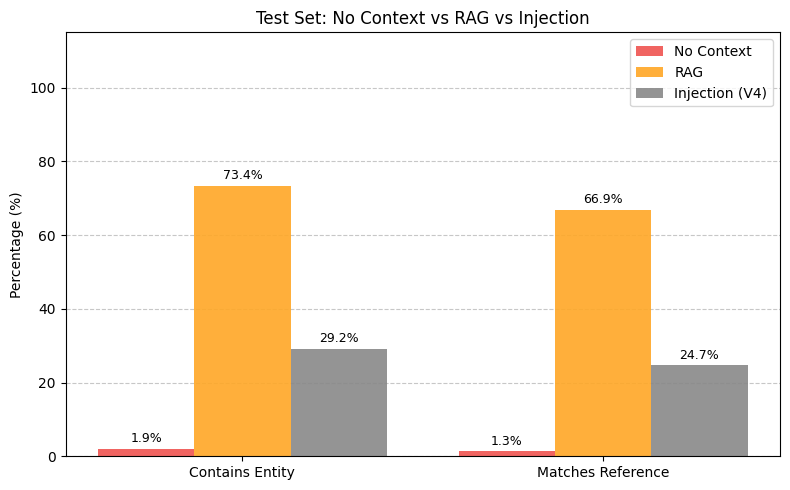

Saved: per_category_contains_entity.png


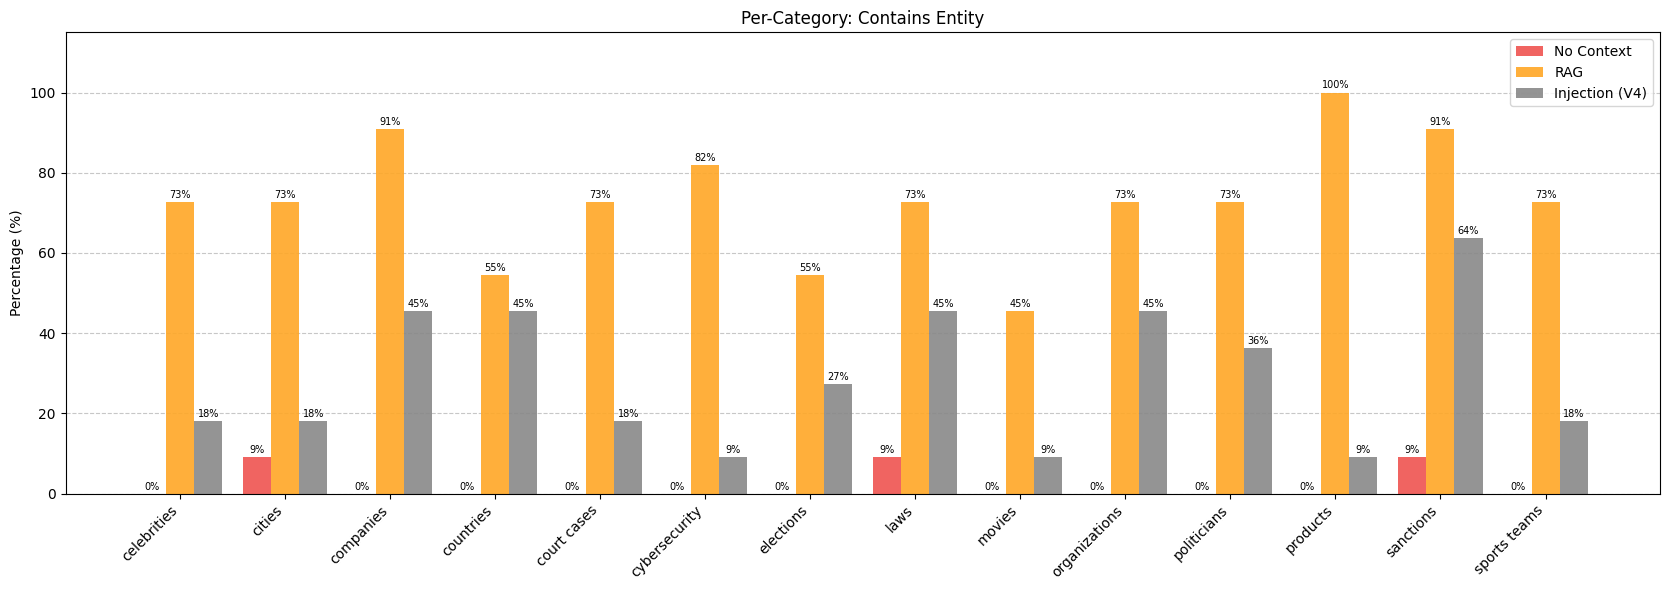

Saved: per_category_matches_reference.png


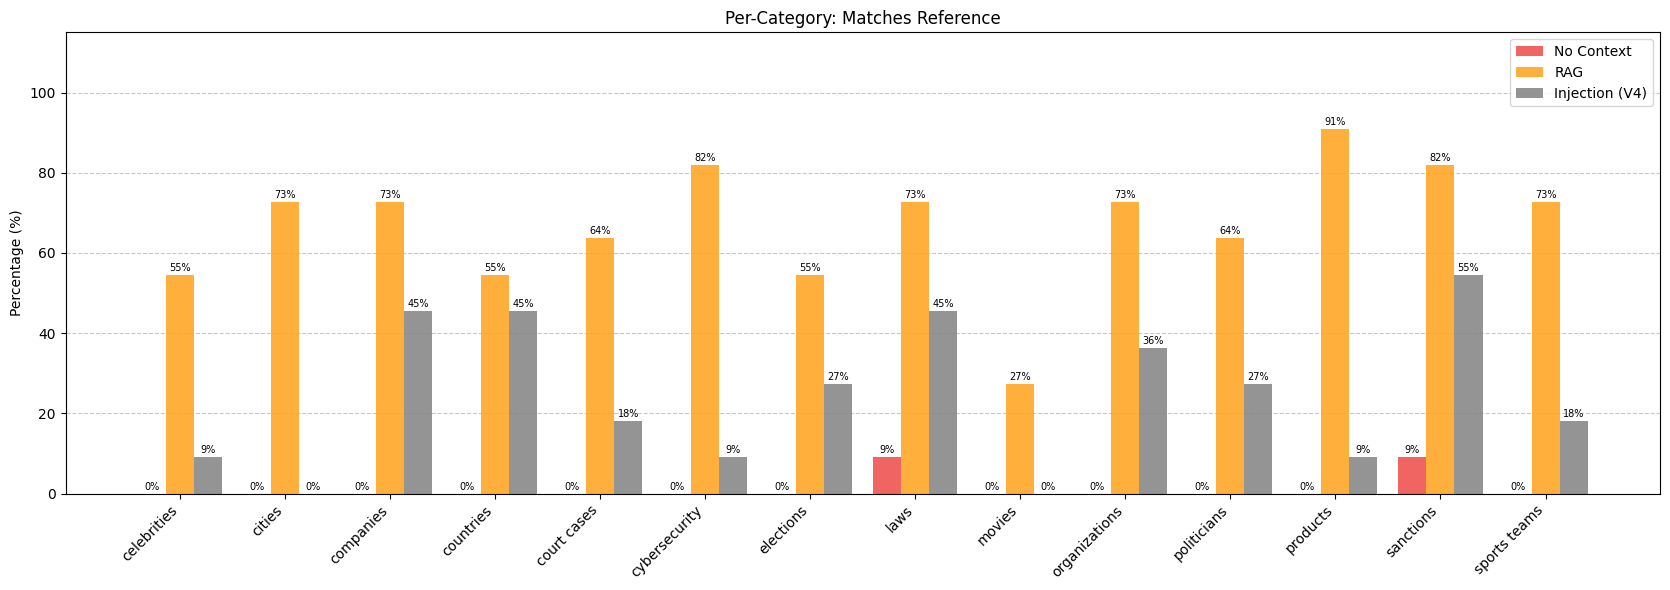


All plots saved to: results_v4/rag_baseline/plots


In [9]:
# ── Visualization ─────────────────────────────────────────────────────────────

PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

approaches = {}
approaches["No Context"] = df_no_ctx_eval
approaches["RAG"]        = df_rag_eval
if has_injection:
    approaches["Injection (V4)"] = df_injection

colors = {"No Context": "#EF5350", "RAG": "#FFA726", "Injection": "#66BB6A"}
n_approaches = len(approaches)

# ── Overall bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)  # CE, MR
width = 0.8 / n_approaches

for i, (name, df) in enumerate(approaches.items()):
    ce, mr = get_scores(df)
    offset = (i - (n_approaches - 1) / 2) * width
    bars = ax.bar(x + offset, [ce, mr], width, label=name,
                  color=colors.get(name, "#888"), alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["Contains Entity", "Matches Reference"])
ax.set_ylim(0, 115)
ax.set_ylabel("Percentage (%)")
ax.set_title("Test Set: No Context vs RAG vs Injection")
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "overall_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Per-category comparison ───────────────────────────────────────────────────
# Use the category column — normalize to lowercase for matching across DataFrames
for name, df in approaches.items():
    if 'category' not in df.columns and 'Category' in df.columns:
        df['category'] = df['Category']
    df['category'] = df['category'].str.lower()

categories = sorted(df_no_ctx_eval['category'].unique())

for metric, metric_label in [("contains_entity", "Contains Entity"),
                              ("matches_reference", "Matches Reference")]:
    fig, ax = plt.subplots(figsize=(max(14, len(categories) * 1.2), 6))
    x = np.arange(len(categories))
    width = 0.8 / n_approaches

    for i, (name, df) in enumerate(approaches.items()):
        cat_scores = []
        for cat in categories:
            subset = df[df['category'] == cat]
            score = 100 * pd.to_numeric(subset[metric], errors='coerce').mean()
            cat_scores.append(score)

        offset = (i - (n_approaches - 1) / 2) * width
        bars = ax.bar(x + offset, cat_scores, width, label=name,
                      color=colors.get(name, "#888"), alpha=0.9)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                        f'{h:.0f}%', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.set_ylim(0, 115)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Per-Category: {metric_label}")
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    plt.tight_layout()
    fname = f"per_category_{metric}.png"
    plt.savefig(os.path.join(PLOTS_DIR, fname), dpi=150, bbox_inches='tight')
    print(f"Saved: {fname}")
    plt.show()
    plt.close()

print(f"\nAll plots saved to: {PLOTS_DIR}")